# Multimodal Fashion Retrieval with Cross-Attention

## 1. Setup and Configuration

In [ ]:
from pathlib import Path
import os
import json
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import kagglehub
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights, densenet121, DenseNet121_Weights
from torchvision import transforms
from tqdm.auto import tqdm
import mlflow
from torch.utils.data import DataLoader, Dataset
import random
from transformers import AutoTokenizer, AutoModel
import copy
import time
from contextlib import nullcontext
import io
from transformers import DistilBertModel
import onnx
import onnxruntime as ort
from torch.export import Dim
import numpy as np
from collections import defaultdict

In [ ]:
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [2]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("multimodal-fashion-retrieval")
print(mlflow.get_tracking_uri())

sqlite:///mlflow.db


## 2. Image Encoder Pretraining on Stanford Online Products

In [5]:
sop_path = kagglehub.dataset_download(
    "liucong12601/stanford-online-products-dataset"
)

sop_path = Path(sop_path)
sop_root = sop_path / "Stanford_Online_Products"

print(sop_path)

C:\Users\fujid\.cache\kagglehub\datasets\liucong12601\stanford-online-products-dataset\versions\1


In [7]:
train_df = pd.read_csv(
    sop_root / "Ebay_train.txt",
    sep=r"\s+"
)

class_ids = train_df["class_id"].unique()
train_classes, val_classes = train_test_split(
    class_ids,
    test_size=0.1,
    random_state=42
)

train_split_df = train_df[
    train_df["class_id"].isin(train_classes)
].reset_index(drop=True)

val_split_df = train_df[
    train_df["class_id"].isin(val_classes)
].reset_index(drop=True)

test_df = pd.read_csv(
    sop_root / "Ebay_test.txt",
    sep=r"\s+"
)

train_class_set = set(train_split_df["class_id"])
val_class_set = set(val_split_df["class_id"])

print(train_class_set & val_class_set)

print("Train images:", len(train_split_df))
print("Val images:", len(val_split_df))

print("Train classes:", train_split_df["class_id"].nunique())
print("Val classes:", val_split_df["class_id"].nunique())

Train images: 53841
Val images: 5710
Train classes: 10186
Val classes: 1132


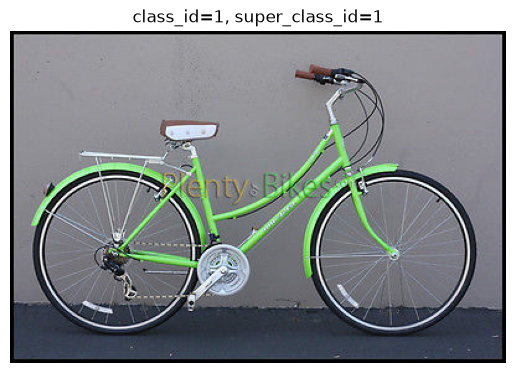

In [11]:
row = train_df.iloc[0]

image_path = sop_root / row["path"]

image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.title(
    f"class_id={row['class_id']}, "
    f"super_class_id={row['super_class_id']}"
)
plt.axis("off")
plt.show()


In [12]:
class TripletDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.class_to_indices = {}
        
        for idx, class_id in enumerate(self.df["class_id"]):
            if class_id not in self.class_to_indices:
                self.class_to_indices[class_id] = []
            
            self.class_to_indices[class_id].append(idx)
        
        self.class_ids = list(self.class_to_indices.keys())
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        anchor_row = self.df.iloc[idx]
        anchor_class = anchor_row["class_id"]
        
        positive_candidates = self.class_to_indices[anchor_class]
        positive_idx = idx
        while positive_idx == idx:
            positive_idx = random.choice(positive_candidates)
        
        positive_row = self.df.iloc[positive_idx]
        
        negative_class = anchor_class
        while negative_class == anchor_class:
            negative_class = random.choice(self.class_ids)
        
        negative_idx = random.choice(self.class_to_indices[negative_class])
        negative_row = self.df.iloc[negative_idx]
        
        anchor_image = Image.open(self.root_dir / anchor_row["path"]).convert("RGB")
        positive_image = Image.open(self.root_dir / positive_row["path"]).convert("RGB")
        
        negative_image = Image.open(self.root_dir / negative_row["path"]).convert("RGB")
        
        if self.transform:
            anchor_image = self.transform(anchor_image)
            positive_image = self.transform(positive_image)
            negative_image = self.transform(negative_image)
        
        return anchor_image, positive_image, negative_image
    

In [13]:
class ValDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.root_dir = Path(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(
            self.root_dir / row["path"]
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, row["class_id"]

In [14]:
train_transform = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
]
)

test_transform = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
]
)

In [15]:
train_dataset = TripletDataset(
    dataframe = train_split_df, 
    root_dir = sop_root, 
    transform = train_transform
)

val_dataset = ValDataset(
    dataframe = val_split_df, 
    root_dir = sop_root, 
    transform = test_transform
)

test_dataset = ValDataset(
    dataframe = test_df, 
    root_dir = sop_root, 
    transform = test_transform
)

print("Val images:", len(val_dataset))
print("Test images:", len(test_dataset))

print(
    "Val classes:",
    val_split_df["class_id"].nunique()
)

print(
    "Test classes:",
    test_df["class_id"].nunique()
)

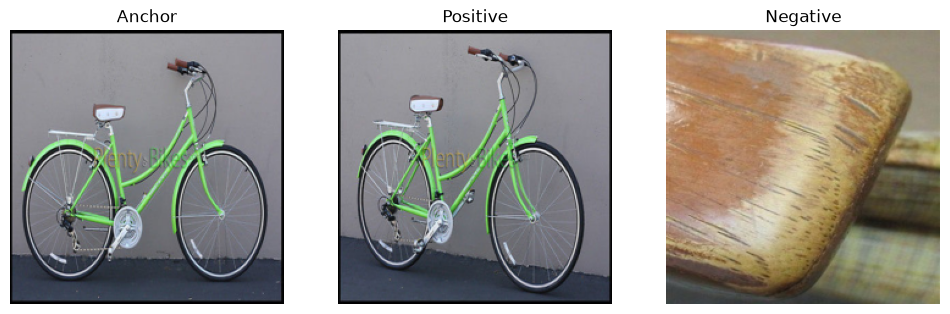

In [17]:
display_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

display_dataset = TripletDataset(
    dataframe=train_df,
    root_dir=sop_root,
    transform=display_transform
)

anchor, positive, negative = display_dataset[0]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(anchor.permute(1, 2, 0))
axes[0].set_title("Anchor")
axes[0].axis("off")

axes[1].imshow(positive.permute(1, 2, 0))
axes[1].set_title("Positive")
axes[1].axis("off")

axes[2].imshow(negative.permute(1, 2, 0))
axes[2].set_title("Negative")
axes[2].axis("off")

plt.show()

In [18]:
class ResNetEncoder(nn.Module):
    def __init__(self, embedding_dim = 256):
        super().__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.projection = nn.Linear(
            in_features,
            embedding_dim
        )
        
    def forward(self, x):
        features = self.backbone(x)
        embedding = self.projection(features)
        
        embedding = F.normalize(
            embedding,
            p = 2,
            dim = 1
        )
        
        return embedding

In [19]:
class DenseNetEncoder(nn.Module):
    def __init__(self, output_dim = 256):
        super().__init__()
        self.backbone = densenet121(
            weights = "DEFAULT"
        )
        
        self.in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Identity()
        
        self.projection = nn.Sequential(
            nn.Linear(self.in_features, 512),
            nn.ReLU(),
            nn.Linear(512, output_dim)
        )
    
    def forward(self, x):
        x = self.backbone(x)
        x = self.projection(x)
        x = F.normalize(x, dim=1)
        
        return x

In [20]:
class SiameseNetwork(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
    
    def forward(self, anchor, positive, negative):
        anchor = self.encoder(anchor)
        positive = self.encoder(positive)
        negative = self.encoder(negative)
        
        return anchor, positive, negative

In [21]:
def recall_at_k(embeddings, labels, k):
    similarity = embeddings @ embeddings.T

    similarity.fill_diagonal_(-float("inf"))

    topk_indices = similarity.topk(
        k=k,
        dim=1
    ).indices

    topk_labels = labels[topk_indices]

    query_labels = labels.unsqueeze(1)

    correct = (
        topk_labels == query_labels
    ).any(dim=1)

    recall = correct.float().mean().item()

    return recall

In [22]:
def train_loop(
    model,
    train_loader,
    val_loader,
    loss_function,
    optimizer,
    device,
    num_epoch,
    batch_size,
    learning_rate,
    weight_decay,
    model_name,
    save_path
):
    model = model.to(device)
    model.train()

    metrics = {
        "train_loss": [],
        "r1": [],
        "r5": [],
        "r10": []
    }
    

    best_r1 = 0.0

    epoch_bar = tqdm(
        range(num_epoch),
        desc="Training"
    )
    
    with mlflow.start_run():
        mlflow.log_param("image_encoder", model_name)
        mlflow.log_param("training_objective", "triplet_loss")
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("weight_decay", weight_decay)
        mlflow.log_param("epoches", num_epoch)
        
        for epoch in epoch_bar:

            # =========================
            # Train
            # =========================
            model.train()

            running_loss = 0.0

            train_bar = tqdm(
                train_loader,
                desc=f"Epoch {epoch + 1}/{num_epoch} [Train]",
                leave=False
            )

            for anchor, positive, negative in train_bar:

                anchor = anchor.to(device)
                positive = positive.to(device)
                negative = negative.to(device)

                optimizer.zero_grad(set_to_none=True)

                anchor_emb, positive_emb, negative_emb = model(
                    anchor,
                    positive,
                    negative
                )

                loss = loss_function(
                    anchor_emb,
                    positive_emb,
                    negative_emb
                )

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * len(anchor)

                train_bar.set_postfix(
                    batch_loss=f"{loss.item():.4f}"
                )

            train_loss = (
                running_loss / len(train_loader.dataset)
            )

            metrics["train_loss"].append(train_loss)


            # =========================
            # Validation
            # =========================
            model.eval()

            encoder = model.encoder

            embeddings = []
            labels = []

            val_bar = tqdm(
                val_loader,
                desc=f"Epoch {epoch + 1}/{num_epoch} [Val]",
                leave=False
            )

            with torch.no_grad():
                for images, batch_labels in val_bar:

                    images = images.to(device)

                    emb = encoder(images)

                    embeddings.append(emb.cpu())
                    labels.append(batch_labels.cpu())

            embeddings = torch.cat(
                embeddings,
                dim=0
            )

            labels = torch.cat(
                labels,
                dim=0
            )


            # =========================
            # Recall@K
            # =========================
            r1 = recall_at_k(
                embeddings=embeddings,
                labels=labels,
                k=1
            )

            r5 = recall_at_k(
                embeddings=embeddings,
                labels=labels,
                k=5
            )

            r10 = recall_at_k(
                embeddings=embeddings,
                labels=labels,
                k=10
            )

            metrics["r1"].append(r1)
            metrics["r5"].append(r5)
            metrics["r10"].append(r10)


            # =========================
            # Save best encoder
            # =========================
            if r1 > best_r1:
                best_r1 = r1

                torch.save(
                    encoder.state_dict(),
                    save_path
                )

            epoch_bar.set_postfix(
                loss=f"{train_loss:.4f}",
                r1=f"{r1:.4f}",
                r5=f"{r5:.4f}",
                r10=f"{r10:.4f}"
            )
            
            mlflow.log_metric(
                "train_loss",
                train_loss,
                step=epoch
            )
            
            mlflow.log_metric(
                "val_r1",
                r1,
                step=epoch
            )
            
            mlflow.log_metric(
                "val_r5",
                r5,
                step=epoch
            )
            
            mlflow.log_metric(
                "val_r10",
                r10,
                step=epoch
            )
            
            

            print(
                f"Epoch {epoch + 1}/{num_epoch} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val R@1: {r1:.4f} | "
                f"Val R@5: {r5:.4f} | "
                f"Val R@10: {r10:.4f}"
            )
            
        mlflow.log_artifact(save_path)
            
    print(f"Best Val R@1: {best_r1:.4f}")

    return metrics

In [23]:
def evaluate(encoder, test_loader, device):
    encoder.to(device)
    embeddings = []
    labels = []
    metrics = {}
    encoder.eval()
    
    with torch.no_grad():
         for images, batch_labels in test_loader:
            images, batch_labels = images.to(device), batch_labels.to(device)
            emb = encoder(images)
                
            embeddings.append(emb.cpu())
            labels.append(batch_labels.cpu())
                
    embeddings = torch.cat(embeddings, dim = 0)
    labels = torch.cat(labels, dim = 0)
            
    r1 = recall_at_k(
        embeddings=embeddings, 
        labels=labels, 
        k=1
    )
        
    r5 = recall_at_k(
        embeddings=embeddings, 
        labels=labels, 
        k=5
    )
        
    r10 = recall_at_k(
        embeddings=embeddings, 
        labels=labels, 
        k=10
    )
        
    metrics["r1"] = r1
    metrics["r5"] = r5
    metrics["r10"] = r10
        
    print(f'test r1: {metrics["r1"]}, test r5: {metrics["r5"]}, test r10: {metrics["r10"]}')
        
    return metrics  

In [24]:
batch_size = 16

train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = batch_size,
    shuffle = True
)

val_loader = DataLoader(
    dataset = val_dataset,
    batch_size = batch_size,
    shuffle = False
)


test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = batch_size,
    shuffle = False
)

In [25]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using Device: CUDA")
elif torch.mps.is_available():
    device = torch.device("mps")
    print("Using Device: MPS")
else:
    device = torch.device("cpu")
    print("Using Device: CPU")

Using Device: CUDA


In [26]:
image_encoder = ResNetEncoder(embedding_dim=256).to(device)
model = SiameseNetwork(image_encoder).to(device)

loss_function = nn.TripletMarginLoss(
    margin=0.2,
    p=2
)

learning_rate = 1e-4
weight_decay = 1e-4

optimizer = optim.AdamW(
    image_encoder.parameters(),
    lr = learning_rate,
    weight_decay = weight_decay
)

In [27]:
num_epoch = 5

In [31]:
train_results_resnet = train_loop(
    model = model, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    loss_function = loss_function, 
    optimizer = optimizer, 
    device = device, 
    num_epoch = num_epoch,
    batch_size = batch_size,
    learning_rate = learning_rate,
    weight_decay = weight_decay,
    model_name = "resnet18",
    save_path = "best_r1_encoder.pth"
)

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 [Train]:   0%|          | 0/3366 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/357 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 0.0239 | Val R@1: 0.5384 | Val R@5: 0.6811 | Val R@10: 0.7457


Epoch 2/5 [Train]:   0%|          | 0/3366 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]:   0%|          | 0/357 [00:00<?, ?it/s]

Epoch 4/5 | Train Loss: 0.0160 | Val R@1: 0.5413 | Val R@5: 0.7044 | Val R@10: 0.7643


Epoch 5/5 [Train]:   0%|          | 0/3366 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/357 [00:00<?, ?it/s]

Epoch 5/5 | Train Loss: 0.0137 | Val R@1: 0.5524 | Val R@5: 0.7068 | Val R@10: 0.7718
Best Val R@1: 0.5524


In [28]:
trained_encoder = ResNetEncoder(
    embedding_dim=256
)

trained_encoder.load_state_dict(
    torch.load(
        "best_r1_encoder.pth",
        map_location=device
    )
)

trained_encoder.eval()

test_result = evaluate(
    trained_encoder,
    test_loader,
    device
)

test r1: 0.3859211206436157, test r5: 0.5333046913146973, test r10: 0.5963273644447327


In [29]:
image_encoder_densenet = DenseNetEncoder(output_dim=256).to(device)
model_densenet = SiameseNetwork(image_encoder_densenet).to(device)

loss_function_densenet = nn.TripletMarginLoss(
    margin=0.2,
    p=2
)

lr_densenet = 1e-4
weight_decay_densenet= 1e-4

optimizer_densenet = optim.AdamW(
    image_encoder_densenet.parameters(),
    lr = lr_densenet,
    weight_decay = weight_decay_densenet
)

In [34]:
train_results_densenet = train_loop(
    model = model_densenet, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    loss_function = loss_function_densenet, 
    optimizer = optimizer_densenet, 
    device = device, 
    num_epoch = num_epoch,
    batch_size = batch_size,
    learning_rate = lr_densenet,
    weight_decay = weight_decay_densenet,
    model_name = "densenet121",
    save_path = "best_r1_densenet_encoder.pth"
)

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 [Train]:   0%|          | 0/3366 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/357 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 0.0215 | Val R@1: 0.5844 | Val R@5: 0.7303 | Val R@10: 0.7904


Epoch 2/5 [Train]:   0%|          | 0/3366 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]:   0%|          | 0/357 [00:00<?, ?it/s]

Epoch 4/5 | Train Loss: 0.0125 | Val R@1: 0.6011 | Val R@5: 0.7641 | Val R@10: 0.8159


Epoch 5/5 [Train]:   0%|          | 0/3366 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/357 [00:00<?, ?it/s]

Epoch 5/5 | Train Loss: 0.0114 | Val R@1: 0.6016 | Val R@5: 0.7518 | Val R@10: 0.8056
Best Val R@1: 0.6016


In [30]:
trained_encoder = DenseNetEncoder(
    output_dim=256
)

trained_encoder.load_state_dict(
    torch.load(
        "best_r1_densenet_encoder.pth",
        map_location=device
    )
)

trained_encoder.eval()

test_result = evaluate(
    trained_encoder,
    test_loader,
    device
)

test r1: 0.42772141098976135, test r5: 0.5781957507133484, test r10: 0.639681339263916


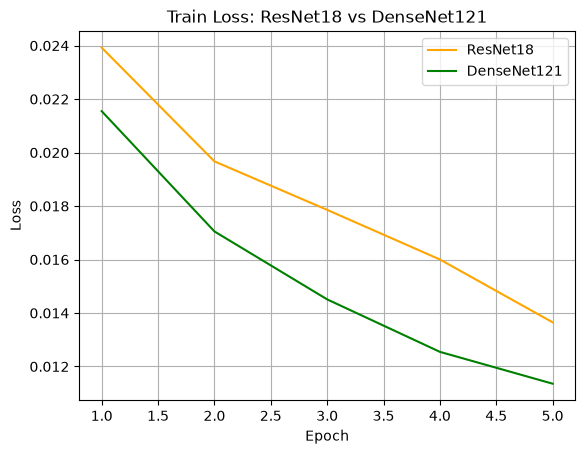

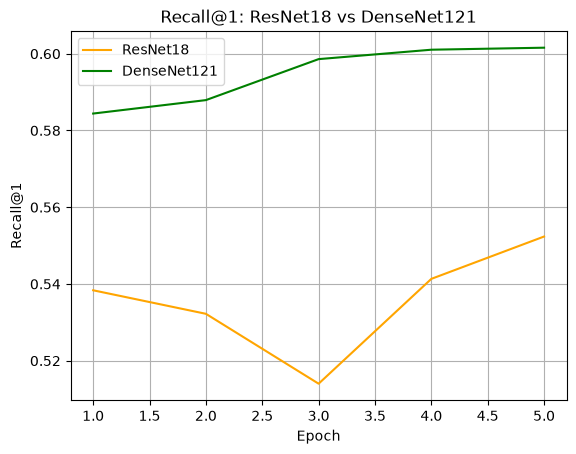

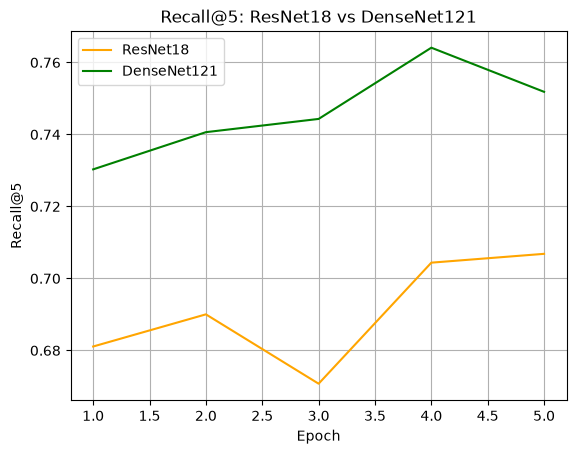

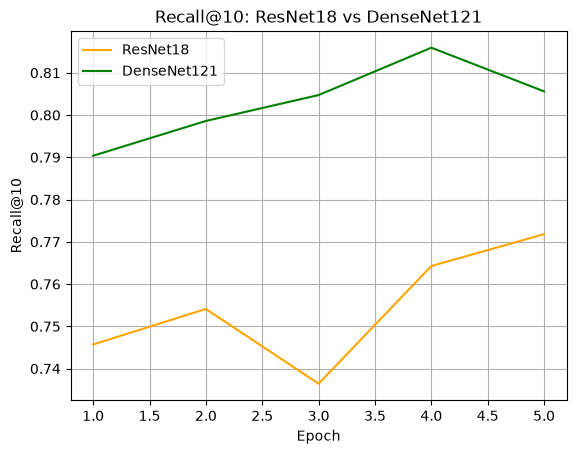

In [48]:
#resnet train_loss vs densenet train_loss
plt.figure()
plt.plot(range(1, num_epoch + 1), train_results_resnet["train_loss"], color="orange", label="ResNet18")
plt.plot(range(1, num_epoch + 1), train_results_densenet["train_loss"], color="green", label="DenseNet121")
plt.title("Train Loss: ResNet18 vs DenseNet121")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

#resnet val r1 vs densenet val r1
plt.figure()
plt.plot(range(1, num_epoch + 1), train_results_resnet["r1"], color="orange", label="ResNet18")
plt.plot(range(1, num_epoch + 1), train_results_densenet["r1"], color="green", label="DenseNet121")
plt.title("Recall@1: ResNet18 vs DenseNet121")
plt.xlabel("Epoch")
plt.ylabel("Recall@1")
plt.grid(True)
plt.legend()
plt.show()

#resnet val r5 vs densenet val r5
plt.figure()
plt.plot(range(1, num_epoch + 1), train_results_resnet["r5"], color="orange", label="ResNet18")
plt.plot(range(1, num_epoch + 1), train_results_densenet["r5"], color="green", label="DenseNet121")
plt.title("Recall@5: ResNet18 vs DenseNet121")
plt.xlabel("Epoch")
plt.ylabel("Recall@5")
plt.grid(True)
plt.legend()
plt.show()

#resnet val r10 vs densenet val r10
plt.figure()
plt.plot(range(1, num_epoch + 1), train_results_resnet["r10"], color="orange", label="ResNet18")
plt.plot(range(1, num_epoch + 1), train_results_densenet["r10"], color="green", label="DenseNet121")
plt.title("Recall@10: ResNet18 vs DenseNet121")
plt.xlabel("Epoch")
plt.ylabel("Recall@10")
plt.grid(True)
plt.legend()
plt.show()

## 3. Hard Negative Mining

In [37]:
class SameSuperclassNegativeTripletDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.root_dir = Path(root_dir)
        self.transform = transform

        self.class_to_indices = defaultdict(list)

        for idx, row in self.df.iterrows():
            self.class_to_indices[row["class_id"]].append(idx)

        self.class_ids = list(self.class_to_indices.keys())

        # class_id -> super_class_id
        self.class_to_superclass = {}

        # super_class_id -> class_ids
        self.superclass_to_classes = defaultdict(list)

        for class_id in self.class_ids:
            first_idx = self.class_to_indices[class_id][0]

            super_class_id = self.df.iloc[first_idx]["super_class_id"]

            self.class_to_superclass[class_id] = super_class_id
            self.superclass_to_classes[super_class_id].append(class_id)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        anchor_row = self.df.iloc[idx]
        anchor_class = anchor_row["class_id"]
        
        positive_candidates = self.class_to_indices[anchor_class]
        positive_idx = idx
        while positive_idx == idx:
            positive_idx = random.choice(positive_candidates)
        
        positive_row = self.df.iloc[positive_idx]
        
        anchor_superclass = self.class_to_superclass[anchor_class]

        negative_candidates = [
            class_id
            for class_id in self.superclass_to_classes[anchor_superclass]
            if class_id != anchor_class
        ]

        negative_class = random.choice(negative_candidates)

        negative_idx = random.choice(
            self.class_to_indices[negative_class]
        )
        
        negative_row = self.df.iloc[negative_idx]
        
        anchor_image = Image.open(self.root_dir / anchor_row["path"]).convert("RGB")
        positive_image = Image.open(self.root_dir / positive_row["path"]).convert("RGB")
        
        negative_image = Image.open(self.root_dir / negative_row["path"]).convert("RGB")
        
        
        if self.transform:
            anchor_image = self.transform(anchor_image)
            positive_image = self.transform(positive_image)
            negative_image = self.transform(negative_image)
        
        return anchor_image, positive_image, negative_image
    

In [38]:
same_superclass_train_dataset = SameSuperclassNegativeTripletDataset(
    dataframe = train_split_df, 
    root_dir = sop_root, 
    transform = train_transform
)

same_superclass_train_loader = DataLoader(
    dataset = same_superclass_train_dataset,
    batch_size = batch_size,
    shuffle = True
)


In [51]:
same_superclass_densenet_encoder = DenseNetEncoder(
    output_dim=256
)

same_superclass_model = SiameseNetwork(
    same_superclass_densenet_encoder
).to(device)

same_superclass_loss_function = nn.TripletMarginLoss(
    margin = 0.2,
    p = 2
)

same_superclass_optimizer = torch.optim.AdamW(
    same_superclass_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

same_superclass_results = train_loop(
    model=same_superclass_model,
    train_loader=same_superclass_train_loader,
    val_loader=val_loader,
    loss_function=same_superclass_loss_function,
    optimizer=same_superclass_optimizer,
    device=device,
    num_epoch=5,
    batch_size = batch_size,
    learning_rate = learning_rate,
    weight_decay = weight_decay,
    model_name = "densenet121",
    save_path = "best_r1_densenet_encoder_same_superclass.pth"
)

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 [Train]:   0%|          | 0/3366 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/357 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 0.0344 | Val R@1: 0.5905 | Val R@5: 0.7261 | Val R@10: 0.7778


Epoch 2/5 [Train]:   0%|          | 0/3366 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]:   0%|          | 0/357 [00:00<?, ?it/s]

Epoch 4/5 | Train Loss: 0.0222 | Val R@1: 0.6005 | Val R@5: 0.7496 | Val R@10: 0.8033


Epoch 5/5 [Train]:   0%|          | 0/3366 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/357 [00:00<?, ?it/s]

Epoch 5/5 | Train Loss: 0.0208 | Val R@1: 0.6047 | Val R@5: 0.7578 | Val R@10: 0.8130
Best Val R@1: 0.6047


In [41]:
trained_encoder = DenseNetEncoder(
    output_dim=256
)

trained_encoder.load_state_dict(
    torch.load(
        "best_r1_densenet_encoder_same_superclass.pth",
        map_location=device
    )
)

same_superclass_test_result = evaluate(
    trained_encoder,
    test_loader,
    device
)

test r1: 0.45725759863853455, test r5: 0.6030709743499756, test r10: 0.6583749055862427


In [42]:
best_image_encoder = trained_encoder

In [43]:
image_encoder = copy.deepcopy(best_image_encoder)
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
text_encoder = AutoModel.from_pretrained(model_name)

for param in image_encoder.parameters():
    param.requires_grad = False

for param in text_encoder.parameters():
    param.requires_grad = False

image_encoder.eval()
text_encoder.eval()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

## 4. FashionIQ Dataset Preparation

In [44]:
# =========================================================
# 1. FashionIQ caption JSON -> DataFrame
# =========================================================

def load_fashioniq_dataframe(caption_path):
    with open(caption_path, "r") as f:
        data = json.load(f)

    rows = []

    for item in data:
        rows.append({
            "reference_id": item["candidate"],
            "target_id": item["target"],
            "text": ". ".join(item["captions"])
        })

    return pd.DataFrame(rows)


# Official train annotations
dataset_path = Path(
    kagglehub.dataset_download(
        "hoangkim14/fashion-iq-dataset"
    )
)

train_caption_path = next(
    dataset_path.rglob("cap.dress.train.json")
)

val_caption_path = next(
    dataset_path.rglob("cap.dress.val.json")
)

full_train_df = load_fashioniq_dataframe(
    train_caption_path
)

official_val_df = load_fashioniq_dataframe(
    val_caption_path
)

jpg_files = list(
    dataset_path.rglob("*.jpg")
)

image_map = {
    path.stem: path
    for path in jpg_files
}

print(
    "Available images:",
    len(image_map)
)


# =========================================================
# 3. Remove queries whose images are unavailable
# =========================================================

available_ids = set(image_map.keys())


def remove_missing_images(dataframe, available_ids):
    return dataframe[
        dataframe["reference_id"].isin(available_ids)
        & dataframe["target_id"].isin(available_ids)
    ].reset_index(drop=True)


full_train_df = remove_missing_images(
    full_train_df,
    available_ids
)

official_val_df = remove_missing_images(
    official_val_df,
    available_ids
)

print(
    "Usable official train queries:",
    len(full_train_df)
)

print(
    "Usable official val queries:",
    len(official_val_df)
)


# =========================================================
# 4. ZERO-OVERLAP train / validation split
# =========================================================


class UnionFind:
    def __init__(self):
        self.parent = {}
        self.rank = {}

    def add(self, x):
        if x not in self.parent:
            self.parent[x] = x
            self.rank[x] = 0

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(
                self.parent[x]
            )
        return self.parent[x]

    def union(self, x, y):
        self.add(x)
        self.add(y)

        root_x = self.find(x)
        root_y = self.find(y)

        if root_x == root_y:
            return

        if self.rank[root_x] < self.rank[root_y]:
            self.parent[root_x] = root_y

        elif self.rank[root_x] > self.rank[root_y]:
            self.parent[root_y] = root_x

        else:
            self.parent[root_y] = root_x
            self.rank[root_x] += 1


def create_query_components(dataframe):
    uf = UnionFind()

    for row in dataframe.itertuples(index=False):
        uf.union(
            row.reference_id,
            row.target_id
        )

    component_rows = {}

    for idx, row in dataframe.iterrows():
        component_id = uf.find(
            row["reference_id"]
        )

        component_rows.setdefault(
            component_id,
            []
        ).append(idx)

    return list(component_rows.values())


components = create_query_components(
    full_train_df
)


def choose_validation_components(
    components,
    total_queries,
    val_ratio=0.1,
    seed=42,
    trials=2000
):
    target_size = int(
        total_queries * val_ratio
    )

    rng = random.Random(seed)

    best_components = None
    best_difference = float("inf")

    for _ in range(trials):
        shuffled = components.copy()
        rng.shuffle(shuffled)

        selected = []
        current_size = 0

        for component in shuffled:
            new_size = (
                current_size
                + len(component)
            )

            if abs(target_size - new_size) <= abs(
                target_size - current_size
            ):
                selected.append(component)
                current_size = new_size

            if current_size >= target_size:
                break

        difference = abs(
            target_size - current_size
        )

        if difference < best_difference:
            best_difference = difference
            best_components = selected

        if difference == 0:
            break

    return best_components


val_components = choose_validation_components(
    components=components,
    total_queries=len(full_train_df),
    val_ratio=0.1,
    seed=42
)

val_indices = set()

for component in val_components:
    val_indices.update(component)

all_indices = set(
    range(len(full_train_df))
)

train_indices = (
    all_indices - val_indices
)

train_df = full_train_df.iloc[
    sorted(train_indices)
].reset_index(drop=True)

val_df = full_train_df.iloc[
    sorted(val_indices)
].reset_index(drop=True)


# =========================================================
# 5. Use official validation as our holdout test set
# =========================================================

test_df = official_val_df.copy()


# =========================================================
# 6. Verify zero overlap
# =========================================================

def get_image_ids(df):
    return (
        set(df["reference_id"])
        | set(df["target_id"])
    )


train_ids = get_image_ids(train_df)
val_ids = get_image_ids(val_df)
test_ids = get_image_ids(test_df)

print("Train queries:", len(train_df))
print("Validation queries:", len(val_df))
print("Test queries:", len(test_df))

print(
    "Train-Val overlap:",
    len(train_ids & val_ids)
)

print(
    "Train-Test overlap:",
    len(train_ids & test_ids)
)

print(
    "Val-Test overlap:",
    len(val_ids & test_ids)
)

assert len(train_ids & val_ids) == 0
assert len(train_ids & test_ids) == 0
assert len(val_ids & test_ids) == 0

Official train queries: 5985
Official val queries: 2017
Available images: 74381
Usable official train queries: 5985
Usable official val queries: 2017
Train queries: 5387
Validation queries: 598
Test queries: 2017
Train-Val overlap: 0
Train-Test overlap: 0


In [45]:
class FusionNetwork(nn.Module):
    def __init__(self, image_dim, text_dim, output_dim):
        super().__init__()
        
        self.fusion = nn.Sequential(
            nn.Linear(image_dim + text_dim, 512),
            nn.ReLU(),
            nn.Linear(512, output_dim)
        )
    
    def forward(self, image_embedding, text_embedding):
        combined = torch.cat(
            [image_embedding, text_embedding], 
            dim = 1
        )
        
        fused_embedding = self.fusion(combined)
        
        fused_embedding = F.normalize(
            fused_embedding,
            p=2,
            dim=1
        )
        
        return fused_embedding

In [46]:
class MultiModalRetrievalModel(nn.Module):
    def __init__(self, image_encoder, text_encoder, image_dim, text_dim, output_dim):
        super().__init__()
        
        self.image_encoder = image_encoder
        self.text_encoder = text_encoder
        self.fusion_encoder = FusionNetwork(
            image_dim = image_dim, 
            text_dim = text_dim, 
            output_dim = output_dim
        )
        
    def encode_query(self, reference_image, input_ids, attention_mask):
        reference_emb = self.image_encoder(
            reference_image
        )

        text_outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        text_emb = (
            text_outputs.last_hidden_state[:, 0, :]
        )

        query_emb = self.fusion_encoder(
            image_embedding=reference_emb,
            text_embedding=text_emb
        )

        return query_emb
    
    def encode_target_image(self, target_image):
        target_emb = self.image_encoder(
            target_image
        )
        
        return target_emb

    def forward(self, reference_image, input_ids, attention_mask, target_image):
        query_emb = self.encode_query(
            reference_image=reference_image,
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        target_emb = self.encode_target_image(
            target_image=target_image
        )
        
        return query_emb, target_emb    

In [47]:
class FashionIQDataset(Dataset):
    def __init__(self, dataframe, image_map, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_map = image_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        reference_image = Image.open(
            self.image_map[row["reference_id"]]
        ).convert("RGB")

        target_image = Image.open(
            self.image_map[row["target_id"]]
        ).convert("RGB")

        if self.transform:
            reference_image = self.transform(reference_image)
            target_image = self.transform(target_image)

        text = row["text"]

        return reference_image, text, target_image

In [48]:
def info_nce_loss(query_emb, target_emb, temperature=0.07):
    logits = (query_emb @ target_emb.T) / temperature

    labels = torch.arange(
        query_emb.size(0),
        device=query_emb.device
    )

    loss_q2t = F.cross_entropy(logits, labels)
    loss_t2q = F.cross_entropy(logits.T, labels)

    return (loss_q2t + loss_t2q) / 2

In [49]:
fashion_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

fashion_train_dataset = FashionIQDataset(
    dataframe=train_df,
    image_map=image_map,
    transform=fashion_transform
)



fashion_val_dataset = FashionIQDataset(
    dataframe=val_df,
    image_map=image_map,
    transform=fashion_transform
)

fashion_test_dataset = FashionIQDataset(
    dataframe=test_df,
    image_map=image_map,
    transform=fashion_transform
)

print(len(fashion_train_dataset))
print(len(fashion_val_dataset))
print(len(fashion_test_dataset))

reference_image, text, target_image = fashion_train_dataset[0]

print(reference_image.shape)
print(text)
print(target_image.shape)

multimodal_batch_size = 16

fashion_train_loader = DataLoader(
    dataset = fashion_train_dataset,
    batch_size = multimodal_batch_size,
    shuffle = True
)

fashion_val_loader = DataLoader(
    dataset = fashion_val_dataset,
    batch_size = multimodal_batch_size,
    shuffle = False
)

fashion_test_loader = DataLoader(
    dataset = fashion_test_dataset,
    batch_size = multimodal_batch_size,
    shuffle = False
)

5387
598
2017
torch.Size([3, 224, 224])
is solid black with no sleeves. is black with straps
torch.Size([3, 224, 224])


## 5. Multimodal Retrieval Models

In [51]:
num_epochs = 10
learning_rate = 1e-4
weight_decay = 1e-4

multimodal_cat_model = MultiModalRetrievalModel(
    image_encoder = image_encoder,
    text_encoder = text_encoder,
    image_dim = 256,
    text_dim = 768,
    output_dim = 256
)



optimizer = torch.optim.AdamW(
    multimodal_cat_model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)


loss_function = info_nce_loss


In [52]:
def multimodal_recall_at_k(query_embeddings, target_embeddings, k):
    similarity = query_embeddings @ target_embeddings.T

    topk_indices = similarity.topk(
        k=k,
        dim=1
    ).indices

    labels = torch.arange(
        query_embeddings.size(0)
    )

    correct = (
        topk_indices == labels.unsqueeze(1)
    ).any(dim=1)

    recall = correct.float().mean().item()

    return recall

In [53]:
def multimodal_train_loop(
    train_loader,
    val_loader,
    loss_function,
    optimizer,
    model,
    epochs,
    device,
    tokenizer,
    save_path,
    cross_attention,
    batch_size,
    learning_rate,
    weight_decay
):
    model = model.to(device)

    multimodal_metrics = {
        "train_loss": [],
        "r1": [],
        "r5": [],
        "r10": []
    }
    
    best_r1 = 0
    
    
    with mlflow.start_run():
        
        mlflow.log_param("image_encoder", "densenet121")
        mlflow.log_param("text_encoder", "distilbert-base-uncased")

        if cross_attention:
            mlflow.log_param("fusion", "cross_attention")
            mlflow.log_param("attention_dim", 256)
            mlflow.log_param("num_attention_heads", 4)
            
        else: 
            mlflow.log_param("fusion", "concatenate")

        mlflow.log_param("loss", "InfoNCE")
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("weight_decay", weight_decay)
        mlflow.log_param("epoches", epochs)
        
        for epoch in range(epochs):
            model.train()

            if cross_attention:
                model.image_encoder.features.eval()
                model.image_encoder.global_projection.eval()
                model.text_encoder.bert.eval()
            else:
                model.image_encoder.eval()
                model.text_encoder.eval()

            running_loss = 0

            train_progress = tqdm(
                train_loader,
                desc=f"Epoch {epoch+1}/{epochs} [Train]"
            )

            for batch in train_progress:
                reference_images = batch[0].to(device)
                texts = list(batch[1])
                target_images = batch[2].to(device)

                encoded_text = tokenizer(
                    texts,
                    padding=True,
                    truncation=True,
                    return_tensors="pt"
                )

                input_ids = encoded_text["input_ids"].to(device)
                attention_mask = encoded_text["attention_mask"].to(device)

                optimizer.zero_grad()

                query_embeddings, target_embeddings, *_ = model(
                    reference_image=reference_images,
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    target_image=target_images
                )

                loss = loss_function(
                    query_embeddings,
                    target_embeddings
                )

                loss.backward()
                optimizer.step()

                running_loss += (
                    loss.item() * reference_images.size(0)
                )

                train_progress.set_postfix(
                    loss=loss.item()
                )

            train_loss = (
                running_loss / len(train_loader.dataset)
            )

            multimodal_metrics["train_loss"].append(
                train_loss
            )

            model.eval()

            val_query_embeddings = []
            val_target_embeddings = []

            validation_progress = tqdm(
                val_loader,
                desc=f"Epoch {epoch+1}/{epochs} [Validation]"
            )

            with torch.no_grad():
                for batch in validation_progress:
                    reference_images = batch[0].to(device)
                    texts = list(batch[1])
                    target_images = batch[2].to(device)

                    encoded_text = tokenizer(
                        texts,
                        padding=True,
                        truncation=True,
                        return_tensors="pt"
                    )

                    input_ids = encoded_text["input_ids"].to(device)
                    attention_mask = encoded_text["attention_mask"].to(device)

                    query_embeddings, target_embeddings, *_ = model(
                        reference_image=reference_images,
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                        target_image=target_images
                    )

                    val_query_embeddings.append(
                        query_embeddings.cpu()
                    )

                    val_target_embeddings.append(
                        target_embeddings.cpu()
                    )

            val_query_embeddings = torch.cat(
                val_query_embeddings,
                dim=0
            )

            val_target_embeddings = torch.cat(
                val_target_embeddings,
                dim=0
            )

            r1 = multimodal_recall_at_k(
                val_query_embeddings,
                val_target_embeddings,
                k=1
            )

            r5 = multimodal_recall_at_k(
                val_query_embeddings,
                val_target_embeddings,
                k=5
            )

            r10 = multimodal_recall_at_k(
                val_query_embeddings,
                val_target_embeddings,
                k=10
            )

            multimodal_metrics["r1"].append(r1)
            multimodal_metrics["r5"].append(r5)
            multimodal_metrics["r10"].append(r10)

            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"R@1: {r1:.4f} | "
                f"R@5: {r5:.4f} | "
                f"R@10: {r10:.4f}"
            )

            if r1 > best_r1:
                best_r1 = r1
                torch.save(model.state_dict(), save_path)
                
                
            mlflow.log_metric("train_loss", train_loss, step=epoch)
            
            mlflow.log_metric("val_r1", r1, step=epoch)
            
            mlflow.log_metric("val_r5", r5, step=epoch)
            
            mlflow.log_metric("val_r10", r10, step=epoch)
        
        print(f"Vest R@1: {best_r1:.4f}")
        mlflow.log_artifact(save_path)

    return multimodal_metrics

In [54]:
def multimodal_evaluate(model, val_loader, device, tokenizer, use_fp16=False):
    model.eval()
    model = model.to(device)

    val_query_embeddings = []
    val_target_embeddings = []

    validation_progress = tqdm(
        val_loader,
        desc="[Validation]"
    )

    with torch.no_grad():
        for batch in validation_progress:
            reference_images = batch[0].to(device)
            texts = list(batch[1])
            target_images = batch[2].to(device)

            encoded_text = tokenizer(
                texts,
                padding=True,
                truncation=True,
                return_tensors="pt"
            )

            input_ids = encoded_text["input_ids"].to(device)
            attention_mask = encoded_text["attention_mask"].to(device)
            
            if use_fp16:
                with torch.autocast(
                    device_type=device.type,
                    dtype=torch.float16
                ):
                    query_embeddings, target_embeddings, *_ = model(
                        reference_image=reference_images,
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                        target_image=target_images
                    )

            else:
                query_embeddings, target_embeddings, *_ = model(
                    reference_image=reference_images,
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    target_image=target_images
                )

            val_query_embeddings.append(
                query_embeddings.float().cpu()
            )

            val_target_embeddings.append(
                target_embeddings.float().cpu()
            )

    val_query_embeddings = torch.cat(
        val_query_embeddings,
        dim=0
    )

    val_target_embeddings = torch.cat(
        val_target_embeddings,
        dim=0
    )

    r1 = multimodal_recall_at_k(
        val_query_embeddings,
        val_target_embeddings,
        k=1
    )

    r5 = multimodal_recall_at_k(
        val_query_embeddings,
        val_target_embeddings,
        k=5
    )

    r10 = multimodal_recall_at_k(
        val_query_embeddings,
        val_target_embeddings,
        k=10
    )

    print(
                f"R@1: {r1:.4f} | "
                f"R@5: {r5:.4f} | "
                f"R@10: {r10:.4f}"
            )


    return r1, r5, r10

### 5.1 Concatenation Baseline

In [67]:
multimodal_train_result = multimodal_train_loop(
    train_loader = fashion_train_loader,
    val_loader = fashion_val_loader,
    loss_function = loss_function,
    optimizer = optimizer,
    model = multimodal_cat_model,
    epochs = 10,
    device = device,
    tokenizer = tokenizer,
    save_path = "best_r1_retrieval_model.pth",
    cross_attention = False,
    batch_size = multimodal_batch_size,
    learning_rate = learning_rate,
    weight_decay = weight_decay
)

Epoch 1/10 [Train]:   0%|          | 0/337 [00:00<?, ?it/s]

Epoch 1/10 [Validation]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 2.5646 | R@1: 0.0100 | R@5: 0.0452 | R@10: 0.0853


Epoch 2/10 [Train]:   0%|          | 0/337 [00:00<?, ?it/s]

Epoch 2/10 [Validation]:   0%|          | 0/38 [00:00<?, ?it/s]

...

Epoch 9/10 [Validation]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 1.9874 | R@1: 0.0251 | R@5: 0.0970 | R@10: 0.1622


Epoch 10/10 [Train]:   0%|          | 0/337 [00:00<?, ?it/s]

Epoch 10/10 [Validation]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 1.9763 | R@1: 0.0151 | R@5: 0.1020 | R@10: 0.1622
Vest R@1: 0.0251


In [55]:
trained_multimodal_model = MultiModalRetrievalModel(
    image_encoder = image_encoder,
    text_encoder = text_encoder,
    image_dim = 256,
    text_dim = 768,
    output_dim = 256
)


trained_multimodal_model.load_state_dict(
    torch.load(
        "best_r1_retrieval_model.pth",
        map_location=device
    )
)

<All keys matched successfully>

In [56]:
test_r1, test_r5, test_r10 = multimodal_evaluate(
    model =  trained_multimodal_model, 
    val_loader = fashion_test_loader,
    device = device,
    tokenizer = tokenizer
)

[Validation]:   0%|          | 0/127 [00:00<?, ?it/s]

R@1: 0.0069 | R@5: 0.0253 | R@10: 0.0466


### 5.2 Cross-Attention Model

In [ ]:
class ImageEncoderForAttention(nn.Module):
    def __init__(self, pretrained_encoder, embedding_dim=256, attention_dim=256):
        super().__init__()

        self.features = copy.deepcopy(
            pretrained_encoder.backbone.features
        )

        feature_dim = pretrained_encoder.in_features  

        self.global_projection = copy.deepcopy(
            pretrained_encoder.projection
        )

        self.token_projection = nn.Linear(
            feature_dim,
            attention_dim
        )

    def forward(self, x):

        # [B, 1024, H, W]
        features = self.features(x)
        features = F.relu(features)

        # =========================
        # Global embedding
        # =========================

        pooled = F.adaptive_avg_pool2d(
            features,
            output_size=(1, 1)
        )

        pooled = torch.flatten(
            pooled,
            start_dim=1
        )

        global_embedding = self.global_projection(
            pooled
        )

        global_embedding = F.normalize(
            global_embedding,
            p=2,
            dim=1
        )

        # =========================
        # Visual tokens
        # =========================

        # [B, 1024, H, W]
        # ->
        # [B, H*W, 1024]

        visual_tokens = features.flatten(2)
        visual_tokens = visual_tokens.transpose(1, 2)

        # [B, H*W, attention_dim]
        visual_tokens = self.token_projection(
            visual_tokens
        )
        
#         visual_tokens = self.positional_encoding(
#             visual_tokens
#         )

        return global_embedding, visual_tokens

In [ ]:
class TextEncoderForAttention(nn.Module):
    def __init__(self, attention_dim=256):
        super().__init__()

        self.bert = DistilBertModel.from_pretrained(
            "distilbert-base-uncased"
        )

        self.projection = nn.Linear(
            768,
            attention_dim
        )

    def forward(self, input_ids,attention_mask):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # [B, sequence_length, 768]
        text_tokens = outputs.last_hidden_state

        # [B, sequence_length, attention_dim]
        text_tokens = self.projection(text_tokens)

        return text_tokens

In [ ]:
class AttentionFusion(nn.Module):
    def __init__(self, attention_dim=256, output_dim=256, num_heads=4):
        super().__init__()

        self.cross_attention = nn.MultiheadAttention(
            embed_dim=attention_dim,
            num_heads=num_heads,
            batch_first=True
        )

        self.fusion = nn.Sequential(
            nn.Linear(attention_dim * 2, 512),
            nn.ReLU(),
            nn.Linear(512, output_dim)
        )

    def forward(self, visual_tokens, text_tokens, attention_mask):

        attended_visual, attention_weights = (
            self.cross_attention(
                query=text_tokens,
                key=visual_tokens,
                value=visual_tokens
            )
        )

        fused_tokens = torch.cat([text_tokens, attended_visual], dim=-1)

        # [B, seq_len, output_dim]
        fused_tokens = self.fusion(fused_tokens)

        mask = attention_mask.unsqueeze(-1)
        mask = mask.float()

        fused_embedding = (fused_tokens * mask).sum(dim=1)

        fused_embedding = (fused_embedding / mask.sum(dim=1).clamp(min=1e-9))

        fused_embedding = F.normalize(fused_embedding, p=2, dim=1)

        return fused_embedding, attention_weights

In [ ]:
class AttentionMultimodalRetrievalModel(nn.Module):
    def __init__(self, pretrained_image_encoder, embedding_dim=256, attention_dim=256, num_heads=4):
        super().__init__()

        self.image_encoder = ImageEncoderForAttention(
            pretrained_encoder=pretrained_image_encoder,
            embedding_dim=embedding_dim,
            attention_dim=attention_dim
        )

        self.text_encoder = TextEncoderForAttention(
            attention_dim=attention_dim
        )

        self.fusion = AttentionFusion(
            attention_dim=attention_dim,
            output_dim=embedding_dim,
            num_heads=num_heads
        )

    def encode_query(
        self,
        reference_image,
        input_ids,
        attention_mask
    ):
        _, reference_visual_tokens = self.image_encoder(
            reference_image
        )

        text_tokens = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        query_embedding, attention_weights = self.fusion(
            visual_tokens=reference_visual_tokens,
            text_tokens=text_tokens,
            attention_mask=attention_mask
        )

        return query_embedding, attention_weights

    def encode_target_image(self, target_image):
        target_embedding, _ = self.image_encoder(
            target_image
        )

        return target_embedding

    def forward(
        self,
        reference_image,
        input_ids,
        attention_mask,
        target_image
    ):
        query_embedding, attention_weights = self.encode_query(
            reference_image=reference_image,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        target_embedding = self.encode_target_image(
            target_image=target_image
        )

        return (
            query_embedding,
            target_embedding,
            attention_weights
        )

## 6. Training and Evaluation

In [71]:
multimodal_attention_model = AttentionMultimodalRetrievalModel(
    pretrained_image_encoder=best_image_encoder,
    embedding_dim=256,
    attention_dim=256,
    num_heads=4
)

for param in multimodal_attention_model.image_encoder.features.parameters():
    param.requires_grad = False

for param in multimodal_attention_model.image_encoder.global_projection.parameters():
    param.requires_grad = False

for param in multimodal_attention_model.text_encoder.bert.parameters():
    param.requires_grad = False


optimizer_attention_model = torch.optim.AdamW([
    {
        "params": multimodal_attention_model.image_encoder.token_projection.parameters(),
        "lr": 1e-4
    },
    {
        "params": multimodal_attention_model.text_encoder.projection.parameters(),
        "lr": 1e-4
    },
    {
        "params": multimodal_attention_model.fusion.parameters(),
        "lr": 1e-4
    }
], weight_decay=1e-4)

multimodal_attention_model_train_result = multimodal_train_loop(
    train_loader = fashion_train_loader,
    val_loader = fashion_val_loader,
    loss_function = loss_function,
    optimizer = optimizer_attention_model,
    model = multimodal_attention_model,
    epochs = 10,
    device = device,
    tokenizer = tokenizer,
    save_path = "best_r1_attention_sop_frozen_model.pth",
    cross_attention = True,
    batch_size = multimodal_batch_size,
    learning_rate = learning_rate,
    weight_decay = weight_decay
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/10 [Train]:   0%|          | 0/337 [00:00<?, ?it/s]

Epoch 1/10 [Validation]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 2.0533 | R@1: 0.0351 | R@5: 0.1739 | R@10: 0.2475


...

Epoch 9/10 [Validation]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 0.1537 | R@1: 0.0886 | R@5: 0.2860 | R@10: 0.3946


Epoch 10/10 [Train]:   0%|          | 0/337 [00:00<?, ?it/s]

Epoch 10/10 [Validation]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.1305 | R@1: 0.0803 | R@5: 0.2742 | R@10: 0.3829
Vest R@1: 0.0987


In [57]:
trained_attention_model = AttentionMultimodalRetrievalModel(
    pretrained_image_encoder=best_image_encoder,
    embedding_dim=256,
    attention_dim=256,
    num_heads=4
)

trained_attention_model.load_state_dict(
    torch.load(
        "best_r1_attention_sop_frozen_model.pth",
        map_location=device
    )
)

test_r1, test_r5, test_r10 = multimodal_evaluate(
    model =  trained_attention_model, 
    val_loader = fashion_test_loader,
    device = device,
    tokenizer = tokenizer
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Validation]:   0%|          | 0/127 [00:00<?, ?it/s]

R@1: 0.0426 | R@5: 0.1373 | R@10: 0.2067


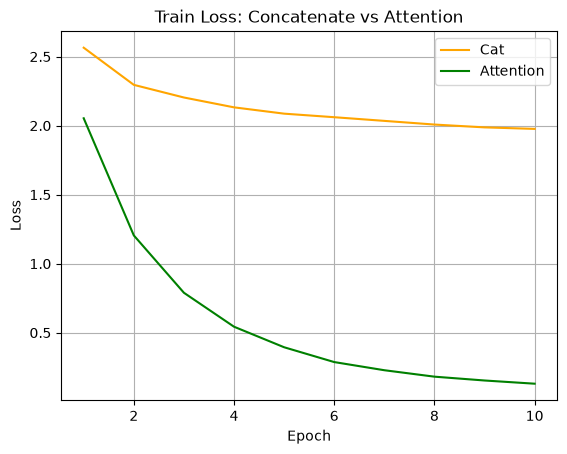

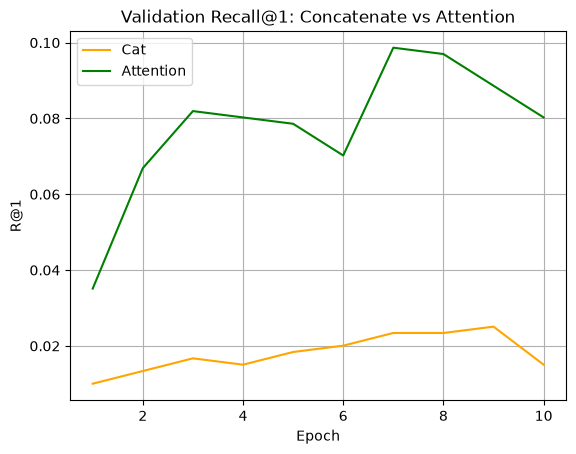

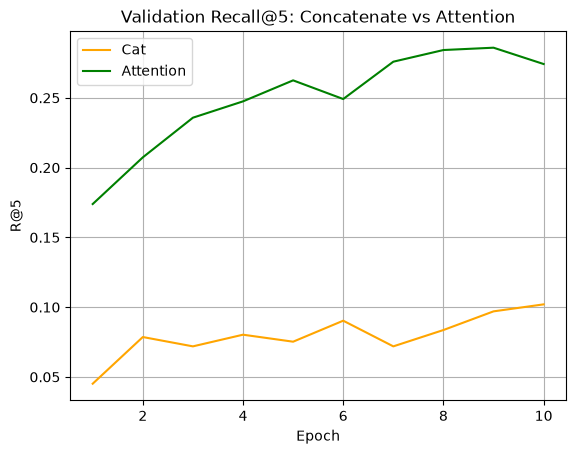

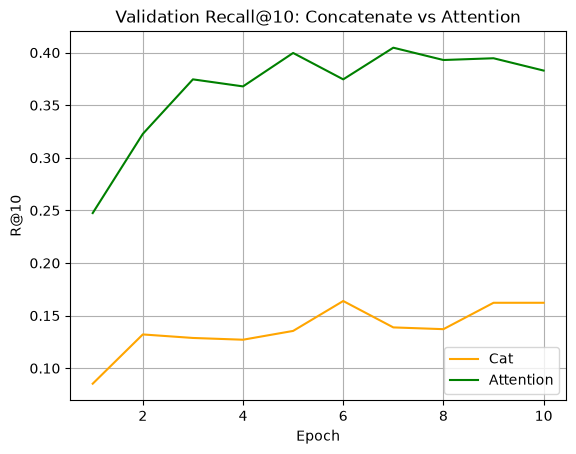

In [73]:
plt.figure()
plt.plot(range(1, num_epochs + 1), multimodal_train_result["train_loss"], color="orange", label = "Cat")
plt.plot(range(1, num_epochs + 1), multimodal_attention_model_train_result["train_loss"], color="green", label = "Attention")
plt.title("Train Loss: Concatenate vs Attention")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(range(1, num_epochs + 1), multimodal_train_result["r1"], color="orange", label = "Cat")
plt.plot(range(1, num_epochs + 1), multimodal_attention_model_train_result["r1"], color="green", label = "Attention")
plt.title("Validation Recall@1: Concatenate vs Attention")
plt.xlabel("Epoch")
plt.ylabel("R@1")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(range(1, num_epochs + 1), multimodal_train_result["r5"], color="orange", label = "Cat")
plt.plot(range(1, num_epochs + 1), multimodal_attention_model_train_result["r5"], color="green", label = "Attention")
plt.title("Validation Recall@5: Concatenate vs Attention")
plt.xlabel("Epoch")
plt.ylabel("R@5")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(range(1, num_epochs + 1), multimodal_train_result["r10"], color="orange", label = "Cat")
plt.plot(range(1, num_epochs + 1), multimodal_attention_model_train_result["r10"], color="green", label = "Attention")
plt.title("Validation Recall@10: Concatenate vs Attention")
plt.xlabel("Epoch")
plt.ylabel("R@10")
plt.grid(True)
plt.legend()
plt.show()

## 7. Catalog Retrieval

In [67]:
def create_catalog_embeddings(model, data_loader, device):
    model.eval()

    all_embeddings = []
    all_ids = []

    with torch.inference_mode():
        for image_ids, images in tqdm(
            data_loader,
            desc="Creating catalog embeddings"
        ):
            images = images.to(device)

            
            embeddings = model.encode_target_image(
                target_image=images
            )

            all_ids.extend(image_ids)
            all_embeddings.append(embeddings.cpu())


    all_embeddings = torch.cat(
        all_embeddings,
        dim=0
    )

    return all_ids, all_embeddings

In [68]:
class CatalogDataset(Dataset):
    def __init__(self, image_ids, image_map, transform):
        self.image_ids = image_ids
        self.image_map = image_map
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image = Image.open(self.image_map[image_id]).convert("RGB")
        image = self.transform(image)

        return image_id, image
        

In [69]:
def create_query_embedding(
    model,
    reference_image,
    text,
    tokenizer,
    transform,
    device
):
    model.eval()

    image_tensor = transform(
        reference_image
    ).unsqueeze(0).to(device)

    encoded_text = tokenizer(
        [text],
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

    input_ids = encoded_text["input_ids"].to(device)
    attention_mask = encoded_text["attention_mask"].to(device)

    with torch.inference_mode():

        query_embedding, attention_weights = model.encode_query(
            reference_image=image_tensor,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

    return query_embedding.cpu()

In [70]:
def search_catalog(
    query_embedding,
    catalog_embeddings,
    catalog_ids,
    top_k=5,
    exclude_id=None
):
    similarities = (
        query_embedding @ catalog_embeddings.T
    ).squeeze(0)

    if exclude_id is not None:
        try:
            exclude_idx = catalog_ids.index(exclude_id)
            similarities[exclude_idx] = -float("inf")
        except ValueError:
            pass

    scores, indices = torch.topk(
        similarities,
        k=top_k
    )

    results = []

    for score, idx in zip(scores, indices):
        results.append({
            "image_id": catalog_ids[idx.item()],
            "score": score.item()
        })

    return results

In [72]:
catalog_ids = sorted(set(full_train_df["reference_id"]) | set(full_train_df["target_id"]) | set(official_val_df["reference_id"]) | set(official_val_df["target_id"]))
print("Catalog Size:", len(catalog_ids))

Catalog Size: 10385


In [73]:
catalog_dataset = CatalogDataset(
    image_ids = catalog_ids,
    image_map = image_map,
    transform = fashion_transform
)

catalog_loader = DataLoader(
    dataset = catalog_dataset,
    batch_size  = 32,
    shuffle = False
)
    

In [ ]:
best_multimodal_model = trained_attention_model

In [74]:
catalog_ids, catalog_embeddings = create_catalog_embeddings(
    model = best_multimodal_model,
    data_loader = catalog_loader,
    device = device
)

print(catalog_embeddings.shape)

Creating catalog embeddings:   0%|          | 0/325 [00:00<?, ?it/s]

torch.Size([10385, 256])


In [75]:
row = test_df.iloc[0]

reference_id = row["reference_id"]
target_id = row["target_id"]
text = row["text"]

reference_image = Image.open(
    image_map[reference_id]
).convert("RGB")

query_embedding = create_query_embedding(
    model=best_multimodal_model,
    reference_image=reference_image,
    text=text,
    tokenizer=tokenizer,
    transform=fashion_transform,
    device=device
)

results = search_catalog(
    query_embedding=query_embedding,
    catalog_embeddings=catalog_embeddings,
    catalog_ids=catalog_ids,
    top_k=5,
    exclude_id=reference_id
)

print("Reference:", reference_id)
print("Text:", text)
print("Expected target:", target_id)
print()

for rank, result in enumerate(results, 1):
    print(
        rank,
        result["image_id"],
        result["score"]
    )

Reference: B005X4PL1G
Text: is shiny and silver with shorter sleeves. fit and flare
Expected target: B0084Y8XIU

1 B00DI7BZI8 0.49074089527130127
2 B008L0LH7G 0.481339693069458
3 B006TALF54 0.47847646474838257
4 B00BY3GQBE 0.47504010796546936
5 B009NF4HEI 0.47495895624160767


## 8. Retrieval Analysis

In [79]:
# =========================================================
# Compare full-test Recall@K vs test Recall@K
# with the same candidate-pool size as validation
# =========================================================

def extract_multimodal_embeddings(
    model,
    data_loader,
    device,
    tokenizer,
    use_fp16=False
):
    model.eval()
    model = model.to(device)

    query_embeddings_list = []
    target_embeddings_list = []

    progress = tqdm(
        data_loader,
        desc="[Extract Test Embeddings]"
    )

    with torch.no_grad():

        for batch in progress:

            reference_images = batch[0].to(device)
            texts = list(batch[1])
            target_images = batch[2].to(device)

            encoded_text = tokenizer(
                texts,
                padding=True,
                truncation=True,
                return_tensors="pt"
            )

            input_ids = encoded_text["input_ids"].to(device)
            attention_mask = encoded_text["attention_mask"].to(device)

            if use_fp16:
                with torch.autocast(
                    device_type=device.type,
                    dtype=torch.float16
                ):
                    query_embeddings, target_embeddings, *_ = model(
                        reference_image=reference_images,
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                        target_image=target_images
                    )

            else:
                query_embeddings, target_embeddings, *_ = model(
                    reference_image=reference_images,
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    target_image=target_images
                )

            query_embeddings_list.append(
                query_embeddings.float().cpu()
            )

            target_embeddings_list.append(
                target_embeddings.float().cpu()
            )

    query_embeddings = torch.cat(
        query_embeddings_list,
        dim=0
    )

    target_embeddings = torch.cat(
        target_embeddings_list,
        dim=0
    )

    return query_embeddings, target_embeddings


def evaluate_fixed_candidate_pool(
    query_embeddings,
    target_embeddings,
    candidate_size,
    num_trials=20,
    seed=42
):
    total_size = query_embeddings.size(0)

    if candidate_size > total_size:
        raise ValueError(
            f"candidate_size={candidate_size} "
            f"is larger than test size={total_size}"
        )

    generator = torch.Generator()
    generator.manual_seed(seed)

    r1_results = []
    r5_results = []
    r10_results = []

    for trial in range(num_trials):

        indices = torch.randperm(
            total_size,
            generator=generator
        )[:candidate_size]

        sampled_query_embeddings = (
            query_embeddings[indices]
        )

        sampled_target_embeddings = (
            target_embeddings[indices]
        )

        r1 = multimodal_recall_at_k(
            sampled_query_embeddings,
            sampled_target_embeddings,
            k=1
        )

        r5 = multimodal_recall_at_k(
            sampled_query_embeddings,
            sampled_target_embeddings,
            k=5
        )

        r10 = multimodal_recall_at_k(
            sampled_query_embeddings,
            sampled_target_embeddings,
            k=10
        )

        r1_results.append(r1)
        r5_results.append(r5)
        r10_results.append(r10)

        print(
            f"Trial {trial + 1:02d} | "
            f"R@1: {r1:.4f} | "
            f"R@5: {r5:.4f} | "
            f"R@10: {r10:.4f}"
        )

    r1_tensor = torch.tensor(r1_results)
    r5_tensor = torch.tensor(r5_results)
    r10_tensor = torch.tensor(r10_results)

    results = {
        "r1_mean": r1_tensor.mean().item(),
        "r1_std": r1_tensor.std().item(),

        "r5_mean": r5_tensor.mean().item(),
        "r5_std": r5_tensor.std().item(),

        "r10_mean": r10_tensor.mean().item(),
        "r10_std": r10_tensor.std().item()
    }

    print()
    print("=" * 60)
    print(
        f"Fixed Test Candidate Pool = {candidate_size}"
    )
    print(
        f"Trials = {num_trials}"
    )
    print()

    print(
        f"R@1  = "
        f"{results['r1_mean']:.4f} "
        f"± {results['r1_std']:.4f}"
    )

    print(
        f"R@5  = "
        f"{results['r5_mean']:.4f} "
        f"± {results['r5_std']:.4f}"
    )

    print(
        f"R@10 = "
        f"{results['r10_mean']:.4f} "
        f"± {results['r10_std']:.4f}"
    )

    print("=" * 60)

    return results


# =========================================================
# 1. Extract full test embeddings once
# =========================================================

test_query_embeddings, test_target_embeddings = (
    extract_multimodal_embeddings(
        model=trained_attention_model,
        data_loader=fashion_test_loader,
        device=device,
        tokenizer=tokenizer,
        use_fp16=False
    )
)

print()
print(
    "Test query embeddings:",
    test_query_embeddings.shape
)

print(
    "Test target embeddings:",
    test_target_embeddings.shape
)


# =========================================================
# 2. Full Test Recall@K
# =========================================================

full_test_r1 = multimodal_recall_at_k(
    test_query_embeddings,
    test_target_embeddings,
    k=1
)

full_test_r5 = multimodal_recall_at_k(
    test_query_embeddings,
    test_target_embeddings,
    k=5
)

full_test_r10 = multimodal_recall_at_k(
    test_query_embeddings,
    test_target_embeddings,
    k=10
)

print()
print("=" * 60)
print(
    f"FULL TEST "
    f"({len(test_query_embeddings)} candidates)"
)

print(
    f"R@1:  {full_test_r1:.4f}"
)

print(
    f"R@5:  {full_test_r5:.4f}"
)

print(
    f"R@10: {full_test_r10:.4f}"
)
print("=" * 60)


# =========================================================
# 3. Evaluate Test using the SAME number of candidates
#    as Validation
# =========================================================

val_candidate_size = len(
    fashion_val_dataset
)

print()
print(
    "Validation candidate size:",
    val_candidate_size
)

fixed_pool_results = evaluate_fixed_candidate_pool(
    query_embeddings=test_query_embeddings,
    target_embeddings=test_target_embeddings,
    candidate_size=val_candidate_size,
    num_trials=20,
    seed=42
)

[Extract Test Embeddings]:   0%|          | 0/127 [00:00<?, ?it/s]


Test query embeddings: torch.Size([2017, 256])
Test target embeddings: torch.Size([2017, 256])

FULL TEST (2017 candidates)
R@1:  0.0426
R@5:  0.1373
R@10: 0.2067

Validation candidate size: 598
Trial 01 | R@1: 0.0836 | R@5: 0.2625 | R@10: 0.3679
Trial 02 | R@1: 0.0886 | R@5: 0.2642 | R@10: 0.3746
Trial 03 | R@1: 0.0836 | R@5: 0.2625 | R@10: 0.3612
Trial 04 | R@1: 0.1003 | R@5: 0.2943 | R@10: 0.4097
Trial 05 | R@1: 0.0970 | R@5: 0.2709 | R@10: 0.3662
Trial 06 | R@1: 0.0803 | R@5: 0.2659 | R@10: 0.3863
Trial 07 | R@1: 0.1054 | R@5: 0.2676 | R@10: 0.3763
Trial 08 | R@1: 0.0936 | R@5: 0.2843 | R@10: 0.3997
Trial 09 | R@1: 0.1070 | R@5: 0.2893 | R@10: 0.3930
Trial 10 | R@1: 0.1070 | R@5: 0.2692 | R@10: 0.4064
Trial 11 | R@1: 0.0903 | R@5: 0.2692 | R@10: 0.3946
Trial 12 | R@1: 0.1054 | R@5: 0.2860 | R@10: 0.3997
Trial 13 | R@1: 0.0987 | R@5: 0.2826 | R@10: 0.3796
Trial 14 | R@1: 0.1003 | R@5: 0.2876 | R@10: 0.3863
Trial 15 | R@1: 0.0920 | R@5: 0.2676 | R@10: 0.3696
Trial 16 | R@1: 0.0953 |

Gallery  250 | R@1: 0.1516 ± 0.0150 | R@5: 0.4018 ± 0.0255 | R@10: 0.5490 ± 0.0318
Gallery  500 | R@1: 0.1095 ± 0.0058 | R@5: 0.3014 ± 0.0109 | R@10: 0.4238 ± 0.0155
Gallery  598 | R@1: 0.0953 ± 0.0126 | R@5: 0.2696 ± 0.0133 | R@10: 0.3847 ± 0.0144
Gallery  750 | R@1: 0.0859 ± 0.0106 | R@5: 0.2387 ± 0.0123 | R@10: 0.3429 ± 0.0130
Gallery 1000 | R@1: 0.0701 ± 0.0064 | R@5: 0.2035 ± 0.0080 | R@10: 0.2998 ± 0.0103
Gallery 1500 | R@1: 0.0530 ± 0.0029 | R@5: 0.1620 ± 0.0048 | R@10: 0.2445 ± 0.0045
Gallery 2017 | R@1: 0.0426 ± 0.0000 | R@5: 0.1373 ± 0.0000 | R@10: 0.2067 ± 0.0000



,Gallery Size,R@1 Mean,R@1 Std,R@5 Mean,R@5 Std,R@10 Mean,R@10 Std
0,250,0.151600,0.014961,0.401800,0.025546,0.549000,0.031759
1,500,0.109500,0.005799,0.301400,0.010899,0.423800,0.015531
2,598,0.095318,0.012619,0.269565,0.013307,0.384699,0.014431
3,750,0.085933,0.010609,0.238667,0.012342,0.342867,0.012980
4,1000,0.070100,0.006447,0.203500,0.007951,0.299800,0.010258
5,1500,0.052967,0.002890,0.161967,0.004805,0.244500,0.004521
6,2017,0.042638,0.000000,0.137333,0.000000,0.206743,0.000000


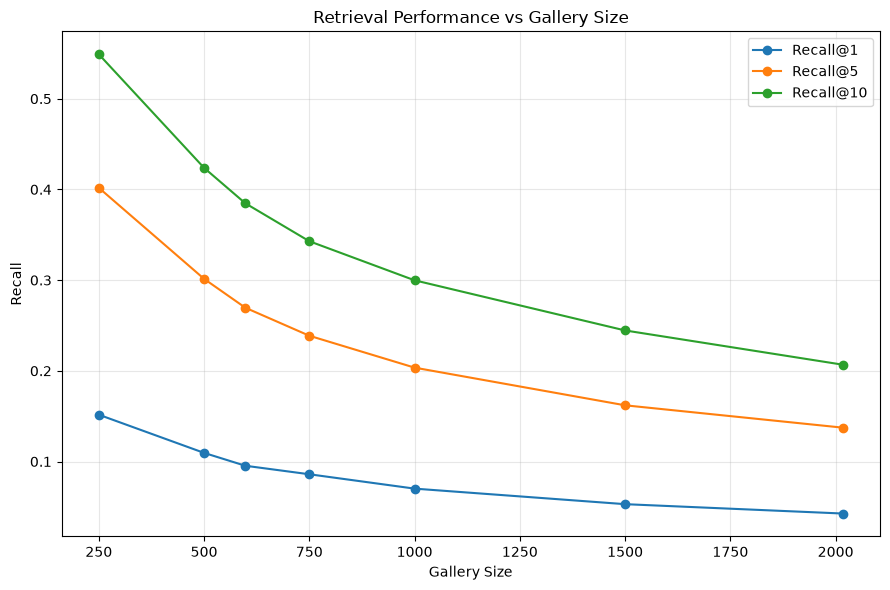

In [80]:
def evaluate_gallery_sizes(
    query_embeddings,
    target_embeddings,
    gallery_sizes,
    num_trials=20,
    seed=42
):
    total_size = query_embeddings.size(0)

    all_results = []

    for gallery_size in gallery_sizes:

        if gallery_size > total_size:
            continue

        r1_results = []
        r5_results = []
        r10_results = []

        if gallery_size == total_size:

            r1 = multimodal_recall_at_k(
                query_embeddings,
                target_embeddings,
                k=1
            )

            r5 = multimodal_recall_at_k(
                query_embeddings,
                target_embeddings,
                k=5
            )

            r10 = multimodal_recall_at_k(
                query_embeddings,
                target_embeddings,
                k=10
            )

            r1_results = [r1]
            r5_results = [r5]
            r10_results = [r10]

        else:

            generator = torch.Generator()
            generator.manual_seed(seed + gallery_size)

            for trial in range(num_trials):

                indices = torch.randperm(
                    total_size,
                    generator=generator
                )[:gallery_size]

                sampled_queries = (
                    query_embeddings[indices]
                )

                sampled_targets = (
                    target_embeddings[indices]
                )

                r1 = multimodal_recall_at_k(
                    sampled_queries,
                    sampled_targets,
                    k=1
                )

                r5 = multimodal_recall_at_k(
                    sampled_queries,
                    sampled_targets,
                    k=5
                )

                r10 = multimodal_recall_at_k(
                    sampled_queries,
                    sampled_targets,
                    k=10
                )

                r1_results.append(r1)
                r5_results.append(r5)
                r10_results.append(r10)

        r1_tensor = torch.tensor(r1_results)
        r5_tensor = torch.tensor(r5_results)
        r10_tensor = torch.tensor(r10_results)

        result = {
            "Gallery Size": gallery_size,

            "R@1 Mean": r1_tensor.mean().item(),
            "R@1 Std": (
                r1_tensor.std().item()
                if len(r1_results) > 1
                else 0.0
            ),

            "R@5 Mean": r5_tensor.mean().item(),
            "R@5 Std": (
                r5_tensor.std().item()
                if len(r5_results) > 1
                else 0.0
            ),

            "R@10 Mean": r10_tensor.mean().item(),
            "R@10 Std": (
                r10_tensor.std().item()
                if len(r10_results) > 1
                else 0.0
            )
        }

        all_results.append(result)

        print(
            f"Gallery {gallery_size:4d} | "
            f"R@1: {result['R@1 Mean']:.4f} ± {result['R@1 Std']:.4f} | "
            f"R@5: {result['R@5 Mean']:.4f} ± {result['R@5 Std']:.4f} | "
            f"R@10: {result['R@10 Mean']:.4f} ± {result['R@10 Std']:.4f}"
        )

    return pd.DataFrame(all_results)


# =========================================================
# Gallery sizes
# 598 = current zero-overlap validation size
# 2017 = full test size
# =========================================================

gallery_sizes = [
    250,
    500,
    598,
    750,
    1000,
    1500,
    2017
]


# =========================================================
# Run evaluation
# =========================================================

gallery_results_df = evaluate_gallery_sizes(
    query_embeddings=test_query_embeddings,
    target_embeddings=test_target_embeddings,
    gallery_sizes=gallery_sizes,
    num_trials=20,
    seed=42
)


print()
display(gallery_results_df)


# =========================================================
# Plot Gallery Size vs Recall@K
# =========================================================

plt.figure(figsize=(9, 6))

plt.plot(
    gallery_results_df["Gallery Size"],
    gallery_results_df["R@1 Mean"],
    marker="o",
    label="Recall@1"
)

plt.plot(
    gallery_results_df["Gallery Size"],
    gallery_results_df["R@5 Mean"],
    marker="o",
    label="Recall@5"
)

plt.plot(
    gallery_results_df["Gallery Size"],
    gallery_results_df["R@10 Mean"],
    marker="o",
    label="Recall@10"
)

plt.xlabel("Gallery Size")
plt.ylabel("Recall")
plt.title("Retrieval Performance vs Gallery Size")

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

## 9. ONNX Export and Validation

In [81]:
class QueryEncoderONNX(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(
        self,
        reference_image,
        input_ids,
        attention_mask
    ):
        query_embedding, _ = self.model.encode_query(
            reference_image=reference_image,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        return query_embedding

In [82]:
onnx_query_model = QueryEncoderONNX(
    copy.deepcopy(best_multimodal_model)
)

onnx_query_model = onnx_query_model.cpu().eval()

In [83]:
row = test_df.iloc[0]

reference_id = row["reference_id"]
text = row["text"]

reference_image = Image.open(
    image_map[reference_id]
).convert("RGB")

reference_tensor = fashion_transform(
    reference_image
).unsqueeze(0).cpu()

encoded_text = tokenizer(
    [text],
    padding=True,
    truncation=True,
    return_tensors="pt"
)

input_ids = encoded_text["input_ids"].cpu()
attention_mask = encoded_text["attention_mask"].cpu()

print(reference_tensor.shape)
print(input_ids.shape)
print(attention_mask.shape)

torch.Size([1, 3, 224, 224])
torch.Size([1, 13])
torch.Size([1, 13])


In [102]:
export_batch = next(iter(fashion_test_loader))

export_reference_images = export_batch[0].cpu()
export_texts = list(export_batch[1])

export_encoded_text = tokenizer(
    export_texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

export_input_ids = export_encoded_text["input_ids"].cpu()
export_attention_mask = export_encoded_text["attention_mask"].cpu()

print("Export input shapes:")
print("reference_image:", export_reference_images.shape)
print("input_ids:", export_input_ids.shape)
print("attention_mask:", export_attention_mask.shape)


batch_size_dynamic = Dim(
    "batch_size",
    min=1,
    max=32
)

sequence_length_dynamic = Dim(
    "sequence_length",
    min=1,
    max=512
)


onnx_program = torch.onnx.export(
    onnx_query_model,
    (
        export_reference_images,
        export_input_ids,
        export_attention_mask
    ),
    input_names=[
        "reference_image",
        "input_ids",
        "attention_mask"
    ],
    output_names=[
        "query_embedding"
    ],
    dynamic_shapes={
        "reference_image": {
            0: batch_size_dynamic
        },
        "input_ids": {
            0: batch_size_dynamic,
            1: sequence_length_dynamic
        },
        "attention_mask": {
            0: batch_size_dynamic,
            1: sequence_length_dynamic
        }
    },
    dynamo=True
)

onnx_program.save(
    "artifacts/query_encoder_dynamic.onnx"
)

print("\nDynamic ONNX export completed")



session = ort.InferenceSession(
    "artifacts/query_encoder_dynamic.onnx",
    providers=["CPUExecutionProvider"]
)


print("\nONNX input shapes:")

for inp in session.get_inputs():
    print(
        inp.name,
        inp.shape,
        inp.type
    )

Export input shapes:
reference_image: torch.Size([16, 3, 224, 224])
input_ids: torch.Size([16, 18])
attention_mask: torch.Size([16, 18])
[torch.onnx] Obtain model graph for `QueryEncoderONNX([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `QueryEncoderONNX([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Users\fujid\anaconda3\envs\multimodal\Lib\copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...


Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.


[torch.onnx] Optimize the ONNX graph... ✅


C:\Users\fujid\anaconda3\envs\multimodal\Lib\site-packages\torch\onnx\_internal\exporter\_onnx_program.py:487: UserWarning: # The axis name: batch_size will not be used, since it shares the same shape constraints with another axis: batch_size.
  rename_mapping = _dynamic_shapes.create_rename_mapping(
C:\Users\fujid\anaconda3\envs\multimodal\Lib\site-packages\torch\onnx\_internal\exporter\_onnx_program.py:487: UserWarning: # The axis name: sequence_length will not be used, since it shares the same shape constraints with another axis: sequence_length.
  rename_mapping = _dynamic_shapes.create_rename_mapping(



Dynamic ONNX export completed

ONNX input shapes:
reference_image ['batch_size', 3, 224, 224] tensor(float)
input_ids ['batch_size', 'sequence_length'] tensor(int64)
attention_mask ['batch_size', 'sequence_length'] tensor(int64)


In [103]:
with torch.inference_mode():
    pytorch_embedding = onnx_query_model(
        reference_tensor,
        input_ids,
        attention_mask
    )

pytorch_embedding = (
    pytorch_embedding
    .cpu()
    .numpy()
)

In [104]:
onnx_embedding = session.run(
    ["query_embedding"],
    {
        "reference_image": reference_tensor.numpy(),
        "input_ids": input_ids.numpy(),
        "attention_mask": attention_mask.numpy()
    }
)[0]

In [105]:
max_abs_diff = np.max(
    np.abs(
        pytorch_embedding
        - onnx_embedding
    )
)

cosine_similarity = (
    pytorch_embedding[0]
    @ onnx_embedding[0]
) / (
    np.linalg.norm(pytorch_embedding[0])
    * np.linalg.norm(onnx_embedding[0])
)

print(
    "Max absolute difference:",
    max_abs_diff
)

print(
    "Cosine similarity:",
    cosine_similarity
)


Max absolute difference: 3.0733645e-07
Cosine similarity: 1.0000001


## 10. Deployment Benchmark

In [111]:
# ============================================================
# Settings
# ============================================================

cuda_device = torch.device("cuda")
cpu_device = torch.device("cpu")

assert torch.cuda.is_available(), "CUDA is not available."

WARMUP_BATCHES = 5
MEASURE_BATCHES = 30

onnx_path = "artifacts/query_encoder_dynamic.onnx"


# ============================================================
# Helpers
# ============================================================

def sync_device(device):
    if device.type == "cuda":
        torch.cuda.synchronize()


def model_size_mb(model):
    buffer = io.BytesIO()
    torch.save(model.state_dict(), buffer)
    return buffer.getbuffer().nbytes / (1024 ** 2)


# ============================================================
# 1. Fixed FP32 target embeddings
# ============================================================

target_model = copy.deepcopy(best_multimodal_model)
target_model = target_model.to(cuda_device).eval()

fixed_target_embeddings = []

with torch.inference_mode():

    for batch in tqdm(
        fashion_test_loader,
        desc="Creating fixed FP32 target embeddings"
    ):

        target_images = batch[2].to(cuda_device)

        target_embeddings = (
            target_model.encode_target_image(
                target_image=target_images
            )
        )

        fixed_target_embeddings.append(
            target_embeddings.float().cpu()
        )

fixed_target_embeddings = torch.cat(
    fixed_target_embeddings,
    dim=0
)

del target_model
torch.cuda.empty_cache()

print(
    "Fixed target embeddings:",
    fixed_target_embeddings.shape
)


# ============================================================
# 2. PyTorch query evaluation
# ============================================================

def evaluate_pytorch_query(
    model,
    data_loader,
    tokenizer,
    device,
    target_embeddings,
    use_fp16=False
):

    model = model.to(device).eval()

    all_query_embeddings = []

    with torch.inference_mode():

        for batch in tqdm(
            data_loader,
            desc=f"Evaluate PyTorch {device.type}"
        ):

            reference_images = batch[0].to(device)
            texts = list(batch[1])

            encoded = tokenizer(
                texts,
                padding=True,
                truncation=True,
                return_tensors="pt"
            )

            input_ids = encoded["input_ids"].to(device)
            attention_mask = encoded["attention_mask"].to(device)

            if use_fp16:
                precision_context = torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16
                )
            else:
                precision_context = nullcontext()

            with precision_context:

                query_embeddings, _ = (
                    model.encode_query(
                        reference_image=reference_images,
                        input_ids=input_ids,
                        attention_mask=attention_mask
                    )
                )

            all_query_embeddings.append(
                query_embeddings.float().cpu()
            )

    all_query_embeddings = torch.cat(
        all_query_embeddings,
        dim=0
    )

    r1 = multimodal_recall_at_k(
        all_query_embeddings,
        target_embeddings,
        k=1
    )

    r5 = multimodal_recall_at_k(
        all_query_embeddings,
        target_embeddings,
        k=5
    )

    r10 = multimodal_recall_at_k(
        all_query_embeddings,
        target_embeddings,
        k=10
    )

    return r1, r5, r10


# ============================================================
# 3. PyTorch query-only latency
# ============================================================

def measure_pytorch_query_latency(
    model,
    data_loader,
    tokenizer,
    device,
    use_fp16=False
):

    model = model.to(device).eval()

    latencies = []

    with torch.inference_mode():

        for batch_idx, batch in enumerate(data_loader):

            reference_images = batch[0].to(device)
            texts = list(batch[1])

            encoded = tokenizer(
                texts,
                padding=True,
                truncation=True,
                return_tensors="pt"
            )

            input_ids = encoded["input_ids"].to(device)
            attention_mask = encoded[
                "attention_mask"
            ].to(device)

            if use_fp16:
                precision_context = torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16
                )
            else:
                precision_context = nullcontext()

            sync_device(device)

            start = time.perf_counter()

            with precision_context:
                query_embeddings, _ = model.encode_query(
                    reference_image=reference_images,
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

            sync_device(device)

            elapsed_ms = (
                time.perf_counter() - start
            ) * 1000

            if batch_idx >= WARMUP_BATCHES:

                latencies.append(
                    elapsed_ms
                    / reference_images.size(0)
                )

            if len(latencies) >= MEASURE_BATCHES:
                break

    return np.mean(latencies)


# ============================================================
# 4. ONNX evaluation
# ============================================================

onnx_session = ort.InferenceSession(
    onnx_path,
    providers=["CPUExecutionProvider"]
)


def evaluate_onnx_query(
    session,
    data_loader,
    tokenizer,
    target_embeddings
):

    all_query_embeddings = []

    for batch in tqdm(
        data_loader,
        desc="Evaluate ONNX"
    ):

        reference_images = batch[0].cpu()
        texts = list(batch[1])

        encoded = tokenizer(
            texts,
            padding=True,
            truncation=True,
            return_tensors="pt"
        )

        input_ids = encoded["input_ids"]
        attention_mask = encoded[
            "attention_mask"
        ]

        query_embeddings = session.run(
            ["query_embedding"],
            {
                "reference_image":
                    reference_images.numpy(),

                "input_ids":
                    input_ids.numpy(),

                "attention_mask":
                    attention_mask.numpy()
            }
        )[0]

        all_query_embeddings.append(
            torch.from_numpy(
                query_embeddings
            ).float()
        )

    all_query_embeddings = torch.cat(
        all_query_embeddings,
        dim=0
    )

    r1 = multimodal_recall_at_k(
        all_query_embeddings,
        target_embeddings,
        k=1
    )

    r5 = multimodal_recall_at_k(
        all_query_embeddings,
        target_embeddings,
        k=5
    )

    r10 = multimodal_recall_at_k(
        all_query_embeddings,
        target_embeddings,
        k=10
    )

    return r1, r5, r10


def measure_onnx_query_latency(
    session,
    data_loader,
    tokenizer
):

    latencies = []

    for batch_idx, batch in enumerate(data_loader):

        reference_images = batch[0].cpu()
        texts = list(batch[1])

        encoded = tokenizer(
            texts,
            padding=True,
            truncation=True,
            return_tensors="pt"
        )

        inputs = {
            "reference_image":
                reference_images.numpy(),

            "input_ids":
                encoded["input_ids"].numpy(),

            "attention_mask":
                encoded["attention_mask"].numpy()
        }

        start = time.perf_counter()

        session.run(
            ["query_embedding"],
            inputs
        )

        elapsed_ms = (
            time.perf_counter() - start
        ) * 1000

        if batch_idx >= WARMUP_BATCHES:

            latencies.append(
                elapsed_ms
                / reference_images.size(0)
            )

        if len(latencies) >= MEASURE_BATCHES:
            break

    return np.mean(latencies)


# ============================================================
# 5. Create models
# ============================================================

fp32_cuda_model = copy.deepcopy(
    best_multimodal_model
).eval()

fp16_cuda_model = copy.deepcopy(
    best_multimodal_model
).eval()

fp32_cpu_model = copy.deepcopy(
    best_multimodal_model
).cpu().eval()

int8_model_query = copy.deepcopy(
    best_multimodal_model
).cpu().eval()

int8_model_query = (
    torch.ao.quantization.quantize_dynamic(
        int8_model_query,
        {nn.Linear},
        dtype=torch.qint8
    )
)


# ============================================================
# 6. Benchmark PyTorch FP32 CUDA
# ============================================================

r1, r5, r10 = evaluate_pytorch_query(
    fp32_cuda_model,
    fashion_test_loader,
    tokenizer,
    cuda_device,
    fixed_target_embeddings,
    use_fp16=False
)

latency = measure_pytorch_query_latency(
    fp32_cuda_model,
    fashion_test_loader,
    tokenizer,
    cuda_device,
    use_fp16=False
)

fp32_cuda_result = {
    "Configuration": "PyTorch FP32",
    "Device": "CUDA",
    "R@1": r1,
    "R@5": r5,
    "R@10": r10,
    "Query Latency (ms/sample)": latency,
    "Size (MB)": model_size_mb(
        fp32_cuda_model
    )
}


# ============================================================
# 7. Benchmark PyTorch FP16 CUDA
# ============================================================

r1, r5, r10 = evaluate_pytorch_query(
    fp16_cuda_model,
    fashion_test_loader,
    tokenizer,
    cuda_device,
    fixed_target_embeddings,
    use_fp16=True
)

latency = measure_pytorch_query_latency(
    fp16_cuda_model,
    fashion_test_loader,
    tokenizer,
    cuda_device,
    use_fp16=True
)

fp16_cuda_result = {
    "Configuration": "PyTorch FP16 Mixed",
    "Device": "CUDA",
    "R@1": r1,
    "R@5": r5,
    "R@10": r10,
    "Query Latency (ms/sample)": latency,

    # autocastなのでweight自体はFP32のまま
    "Size (MB)": model_size_mb(
        fp16_cuda_model
    )
}


# ============================================================
# 8. Benchmark PyTorch FP32 CPU
# ============================================================

r1, r5, r10 = evaluate_pytorch_query(
    fp32_cpu_model,
    fashion_test_loader,
    tokenizer,
    cpu_device,
    fixed_target_embeddings,
    use_fp16=False
)

latency = measure_pytorch_query_latency(
    fp32_cpu_model,
    fashion_test_loader,
    tokenizer,
    cpu_device,
    use_fp16=False
)

fp32_cpu_result = {
    "Configuration": "PyTorch FP32",
    "Device": "CPU",
    "R@1": r1,
    "R@5": r5,
    "R@10": r10,
    "Query Latency (ms/sample)": latency,
    "Size (MB)": model_size_mb(
        fp32_cpu_model
    )
}


# ============================================================
# 9. Benchmark INT8 CPU
# ============================================================

r1, r5, r10 = evaluate_pytorch_query(
    int8_model_query,
    fashion_test_loader,
    tokenizer,
    cpu_device,
    fixed_target_embeddings,
    use_fp16=False
)

latency = measure_pytorch_query_latency(
    int8_model_query,
    fashion_test_loader,
    tokenizer,
    cpu_device,
    use_fp16=False
)

int8_cpu_result = {
    "Configuration": "PyTorch INT8 Dynamic",
    "Device": "CPU",
    "R@1": r1,
    "R@5": r5,
    "R@10": r10,
    "Query Latency (ms/sample)": latency,
    "Size (MB)": model_size_mb(
        int8_model_query
    )
}


# ============================================================
# 10. Benchmark ONNX Runtime CPU
# ============================================================

onnx_r1, onnx_r5, onnx_r10 = (
    evaluate_onnx_query(
        onnx_session,
        fashion_test_loader,
        tokenizer,
        fixed_target_embeddings
    )
)

onnx_latency = (
    measure_onnx_query_latency(
        onnx_session,
        fashion_test_loader,
        tokenizer
    )
)

onnx_size = (
    os.path.getsize(onnx_path)
    / (1024 ** 2)
)

onnx_result = {
    "Configuration": "ONNX Runtime FP32",
    "Device": "CPU",
    "R@1": onnx_r1,
    "R@5": onnx_r5,
    "R@10": onnx_r10,
    "Query Latency (ms/sample)":
        onnx_latency,
    "Size (MB)": onnx_size
}


# ============================================================
# 11. Final comparison table
# ============================================================

comparison_table = pd.DataFrame([
    fp32_cuda_result,
    fp16_cuda_result,
    fp32_cpu_result,
    onnx_result,
    int8_cpu_result
])

comparison_table = comparison_table.round({
    "R@1": 4,
    "R@5": 4,
    "R@10": 4,
    "Query Latency (ms/sample)": 2,
    "Size (MB)": 2
})

comparison_table

Creating fixed FP32 target embeddings:   0%|          | 0/127 [00:00<?, ?it/s]

Fixed target embeddings: torch.Size([2017, 256])


C:\Users\fujid\AppData\Local\Temp\ipykernel_9524\1144807718.py:406: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  torch.ao.quantization.quantize_dynamic(


Evaluate PyTorch cuda:   0%|          | 0/127 [00:00<?, ?it/s]

Evaluate PyTorch cuda:   0%|          | 0/127 [00:00<?, ?it/s]

Evaluate PyTorch cpu:   0%|          | 0/127 [00:00<?, ?it/s]

Evaluate PyTorch cpu:   0%|          | 0/127 [00:00<?, ?it/s]

Evaluate ONNX:   0%|          | 0/127 [00:00<?, ?it/s]

,Configuration,Device,R@1,R@5,R@10,Query Latency (ms/sample),Size (MB)
0,PyTorch FP32,CUDA,0.0426,0.1373,0.2067,1.12,285.58
1,PyTorch FP16 Mixed,CUDA,0.0426,0.1363,0.2072,1.25,285.58
2,PyTorch FP32,CPU,0.0426,0.1373,0.2053,16.89,285.57
3,ONNX Runtime FP32,CPU,0.0426,0.1373,0.2053,11.39,286.11
4,PyTorch INT8 Dynamic,CPU,0.0288,0.1101,0.1651,15.64,160.91


## 11. Export Deployment Artifacts

In [112]:
np.save(
    "artifacts/catalog_embeddings.npy",
    catalog_embeddings.cpu().numpy()
)

with open(
    "artifacts/catalog_ids.json",
    "w"
) as f:
    json.dump(catalog_ids, f)

tokenizer.save_pretrained(
    "artifacts/tokenizer"
)

('artifacts/tokenizer\\tokenizer_config.json',
 'artifacts/tokenizer\\tokenizer.json')